# Homework 08: Exploratory Data Analysis

This notebook performs a complete EDA on a reproducible ETF-style panel. It remains self-contained in `homework08/` and does not modify the ongoing course project.

In [1]:
# Packages used: numpy, pandas, matplotlib, and seaborn

## 1. Create and Load the Dataset

Four ETF-like series represent equity, bonds, gold, and real estate. Their levels, volatility, and trading volumes differ, and one large SPY shock plus a small amount of missing volume are included for EDA.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW = Path('data/raw')
RAW.mkdir(parents=True, exist_ok=True)

dates = pd.bdate_range('2024-01-02', periods=180)
specs = {
    'SPY': (0.00035, 0.010, 480, 80_000_000),
    'TLT': (0.00010, 0.007, 95, 35_000_000),
    'GLD': (0.00020, 0.008, 190, 12_000_000),
    'VNQ': (0.00015, 0.011, 85, 6_000_000),
}
rng = np.random.default_rng(8)
records = []
for ticker, (drift, volatility, start_price, base_volume) in specs.items():
    returns = rng.normal(drift, volatility, len(dates))
    if ticker == 'SPY':
        returns[75] = -0.065
    close = start_price * np.cumprod(1 + returns)
    volume = base_volume * (1 + 7 * np.abs(returns)) * rng.lognormal(0, 0.12, len(dates))
    records.append(pd.DataFrame({
        'date': dates,
        'ticker': ticker,
        'close': close,
        'volume': volume,
        'daily_return': returns,
    }))

df = pd.concat(records, ignore_index=True)
missing_rows = rng.choice(df.index, size=8, replace=False)
df.loc[missing_rows, 'volume'] = np.nan
df['abs_return'] = df['daily_return'].abs()
raw_path = RAW / 'etf_prices.csv'
df.to_csv(raw_path, index=False)
df.head()

,date,ticker,close,volume,daily_return,abs_return
0,2024-01-02,SPY,471.824321,8.916766e+07,-0.017033,0.017033
1,2024-01-03,SPY,465.682854,8.835773e+07,-0.013016,0.013016
2,2024-01-04,SPY,459.507402,9.367313e+07,-0.013261,0.013261
3,2024-01-05,SPY,458.052523,8.639271e+07,-0.003166,0.003166
4,2024-01-08,SPY,447.620003,8.189791e+07,-0.022776,0.022776


## 2. Structure, Missingness, and Numeric Profile

In [3]:
import seaborn as sns

sns.set_theme(style='whitegrid')
df.info()
display(df.isna().sum().to_frame('missing'))
numeric_profile = df.select_dtypes(include='number').describe().T
numeric_profile['skew'] = df.select_dtypes(include='number').skew()
numeric_profile['kurtosis'] = df.select_dtypes(include='number').kurtosis()
numeric_profile

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          720 non-null    datetime64[ns]
 1   ticker        720 non-null    object        
 2   close         720 non-null    float64       
 3   volume        712 non-null    float64       
 4   daily_return  720 non-null    float64       
 5   abs_return    720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 33.9+ KB


,missing
date,0
ticker,0
close,0
volume,8
daily_return,0
abs_return,0


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
close,720.0,2.064599e+02,1.501375e+02,7.344526e+01,9.232258e+01,1.385420e+02,2.567993e+02,4.845899e+02,0.969227,-0.819746
volume,712.0,3.523745e+07,3.169120e+07,4.371487e+06,9.459910e+06,2.823319e+07,6.340449e+07,1.204932e+08,0.875409,-0.643112
daily_return,720.0,-1.190099e-04,9.540368e-03,-6.500000e-02,-5.822937e-03,1.350116e-05,5.579179e-03,2.573098e-02,-0.409670,2.875809
abs_return,720.0,7.227482e-03,6.222834e-03,3.315693e-05,2.541281e-03,5.658862e-03,1.042561e-02,6.500000e-02,1.993857,10.323855


## 3. Categorical Profile

`ticker` is nominal and has no natural order. `date` is handled as the time index rather than as a category.

Categorical profile: ticker


,count,proportion
ticker,,
SPY,180,0.25
TLT,180,0.25
GLD,180,0.25
VNQ,180,0.25


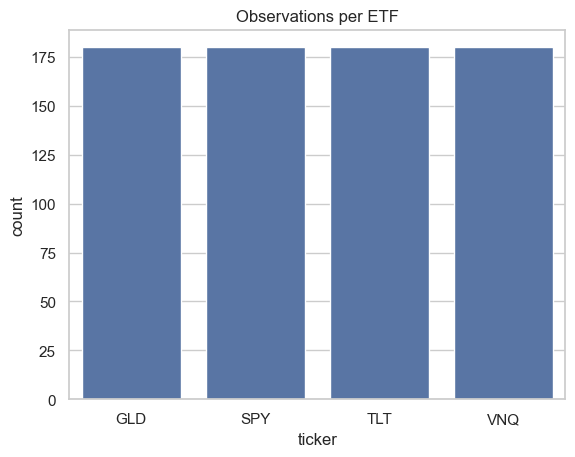

In [4]:
categorical_columns = df.select_dtypes(include=['object', 'category', 'bool']).columns
for column in categorical_columns:
    profile = pd.DataFrame({
        'count': df[column].value_counts(dropna=False),
        'proportion': df[column].value_counts(normalize=True, dropna=False),
    })
    print(f'Categorical profile: {column}')
    display(profile)

sns.countplot(data=df, x='ticker', order=sorted(df['ticker'].unique()))
plt.title('Observations per ETF')
plt.show()

## 4. Distributions

Returns are centered near zero, volume is right-skewed, and price levels differ across ETFs. These differences suggest return-based or normalized features are more comparable than raw prices.

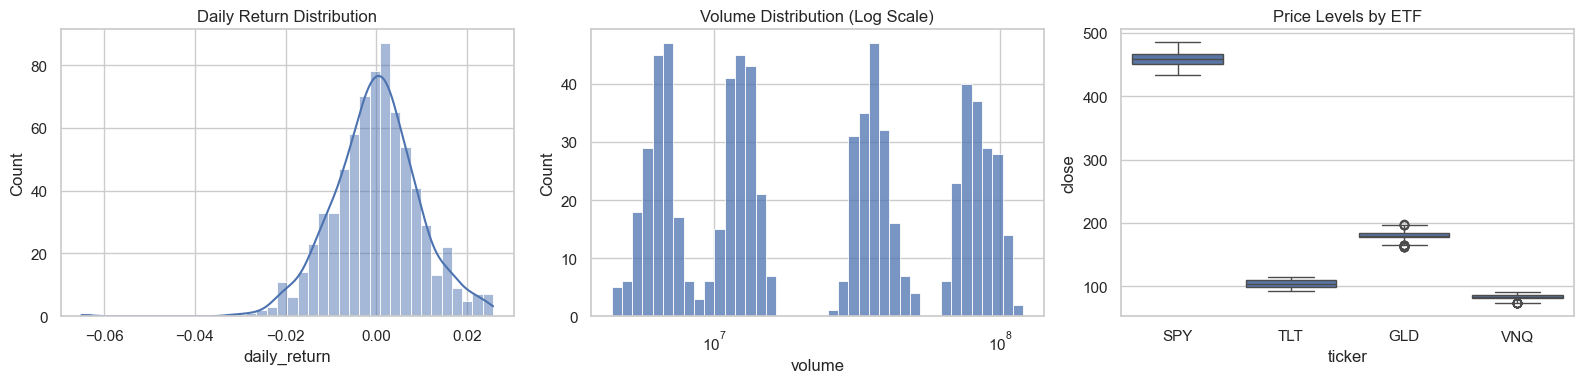

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['daily_return'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Daily Return Distribution')
sns.histplot(df['volume'], bins=40, log_scale=True, ax=axes[1])
axes[1].set_title('Volume Distribution (Log Scale)')
sns.boxplot(data=df, x='ticker', y='close', ax=axes[2])
axes[2].set_title('Price Levels by ETF')
plt.tight_layout()
plt.show()

## 5. Relationships

The first plot checks whether high-volume days coincide with larger moves. The second shows that raw price and volume relationships differ by ETF, so pooled level regressions would need ticker controls or normalization.

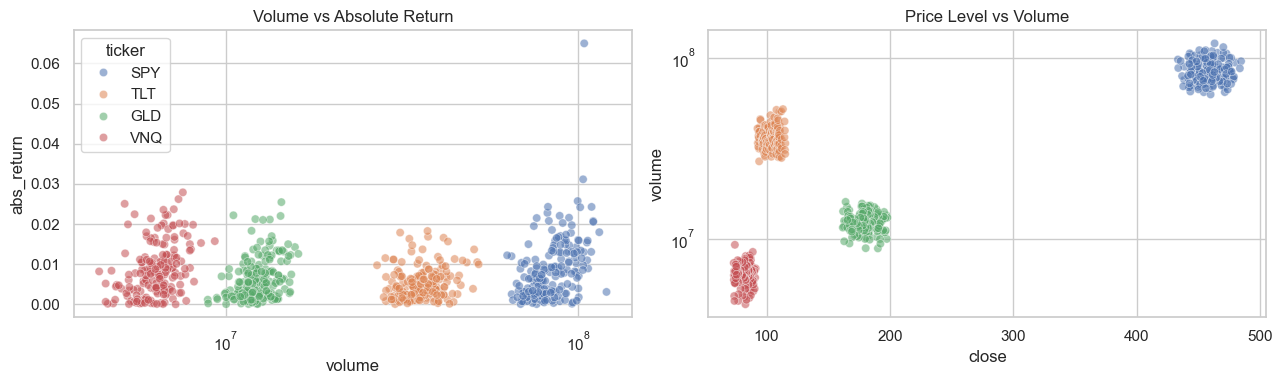

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=df, x='volume', y='abs_return', hue='ticker', alpha=0.55, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Volume vs Absolute Return')
sns.scatterplot(data=df, x='close', y='volume', hue='ticker', alpha=0.55, ax=axes[1], legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Price Level vs Volume')
plt.tight_layout()
plt.show()

## 6. Time-Series View and Date Gaps

Prices are sorted within ticker before rolling calculations. Expected business dates are compared with observed dates so an unnoticed gap cannot distort a rolling feature.

Missing business dates: {'GLD': 0, 'SPY': 0, 'TLT': 0, 'VNQ': 0}


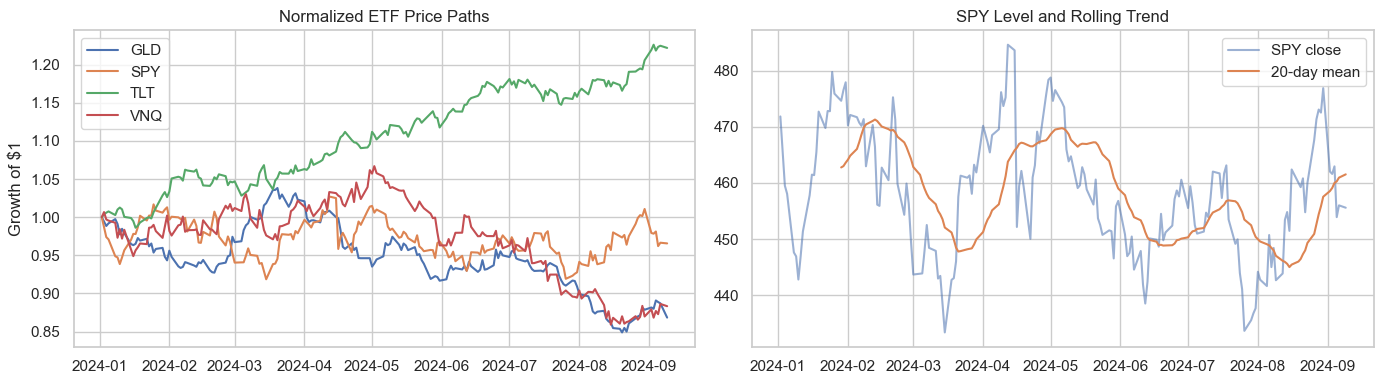

In [7]:
ordered = df.sort_values(['ticker', 'date']).copy()
gap_counts = {}
for ticker, group in ordered.groupby('ticker'):
    expected = pd.bdate_range(group['date'].min(), group['date'].max())
    gap_counts[ticker] = len(expected.difference(group['date']))
print('Missing business dates:', gap_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ticker, group in ordered.groupby('ticker'):
    axes[0].plot(group['date'], group['close'] / group['close'].iloc[0], label=ticker)
axes[0].set_title('Normalized ETF Price Paths')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()

spy = ordered.loc[ordered['ticker'] == 'SPY'].copy()
spy['rolling_20d'] = spy['close'].rolling(20).mean()
axes[1].plot(spy['date'], spy['close'], alpha=0.55, label='SPY close')
axes[1].plot(spy['date'], spy['rolling_20d'], label='20-day mean')
axes[1].set_title('SPY Level and Rolling Trend')
axes[1].legend()
plt.tight_layout()
plt.show()

The normalized price paths show different medium-term trends across asset classes. The SPY shock creates a visible level change, while the rolling mean smooths daily noise and reacts with a lag. No business-date gaps are expected in the generated panel.

## 7. Correlation Matrix

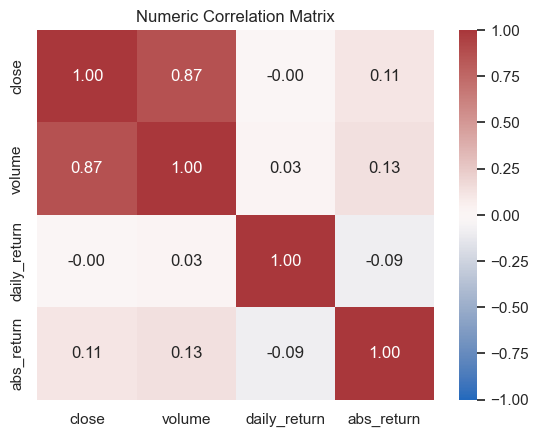

,close,volume,daily_return,abs_return
close,1.000000,0.873876,-0.004606,0.113977
volume,0.873876,1.000000,0.025325,0.133295
daily_return,-0.004606,0.025325,1.000000,-0.093513
abs_return,0.113977,0.133295,-0.093513,1.000000


In [8]:
corr = df[['close', 'volume', 'daily_return', 'abs_return']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Numeric Correlation Matrix')
plt.show()
corr

## 8. Reusable EDA Helper

In [9]:
from src.eda import eda_summary

summary = eda_summary(df)
print('Shape:', summary['shape'])
print('Attention flags:', summary['attention'])
display(summary['numeric_profile'])

Shape: (720, 6)
Attention flags: {'high_missing': [], 'near_zero_variance': [], 'dominant_category': []}


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
close,720.0,2.064599e+02,1.501375e+02,7.344526e+01,9.232258e+01,1.385420e+02,2.567993e+02,4.845899e+02,0.969227,-0.819746
volume,712.0,3.523745e+07,3.169120e+07,4.371487e+06,9.459910e+06,2.823319e+07,6.340449e+07,1.204932e+08,0.875409,-0.643112
daily_return,720.0,-1.190099e-04,9.540368e-03,-6.500000e-02,-5.822937e-03,1.350116e-05,5.579179e-03,2.573098e-02,-0.409670,2.875809
abs_return,720.0,7.227482e-03,6.222834e-03,3.315693e-05,2.541281e-03,5.658862e-03,1.042561e-02,6.500000e-02,1.993857,10.323855


## 9. Top Insights, Assumptions, and Next Steps

1. **Scale differs across ETFs.** Raw prices and volumes are not directly comparable, so Stage 09 should use returns, ratios, and within-ticker transformations.
2. **Returns contain a genuine-looking shock.** A model should preserve the raw event and report sensitivity rather than automatically delete it.
3. **Volume rises with absolute movement by construction.** Rolling volume and volatility features may capture changing market activity, but correlation alone is not causal evidence.

Assumptions include complete business-day coverage, adjusted-like price behavior, and no transaction-cost effects. Next, create momentum, rolling volatility, and ticker encodings, then test them against future rather than same-day returns to avoid leakage.